# TP3 — 06: Interpretacion del modelo y del lenguaje

**Objetivo:** ir mas alla de las metricas y responder las preguntas guia de la
consigna: que palabras definen cada polaridad, que se interpreta con la **similitud
coseno** (metrica vista en clase, requisito mandatorio), de que hablan los tweets de
cada clase (topicos), que errores comete el modelo (sarcasmo/ambiguedad) y que
patrones agregados aparecen por usuario.

Todo se calcula con el **modelo final entrenado sobre los 1.600.000 tweets**.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import MiniBatchNMF
from sklearn.feature_extraction.text import TfidfVectorizer

from utils import (
    SEED,
    TARGET,
    TRAIN_CLEAN_PARQUET,
    DATA_PROCESSED,
    VECTORIZER_JOBLIB,
    MODELO_JOBLIB,
    guardar_fig,
    COLOR_NEG,
    COLOR_POS,
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})
pd.set_option("display.max_colwidth", 140)

vec = joblib.load(VECTORIZER_JOBLIB)
lr = joblib.load(MODELO_JOBLIB)
train = pd.read_parquet(TRAIN_CLEAN_PARQUET)
assert len(train) == 1_600_000
vocab = vec.get_feature_names_out()
print(f"Modelo final cargado: {len(vocab):,} n-gramas en el vocabulario")

Modelo final cargado: 379,089 n-gramas en el vocabulario


## 1. Que aprendio el modelo: coeficientes por n-grama

En una regresion logistica sobre TF-IDF, cada n-grama tiene un coeficiente: positivo
empuja hacia sentimiento positivo, negativo hacia el negativo. Son las "palabras
mas predictivas", que no coinciden necesariamente con las mas frecuentes del EDA.

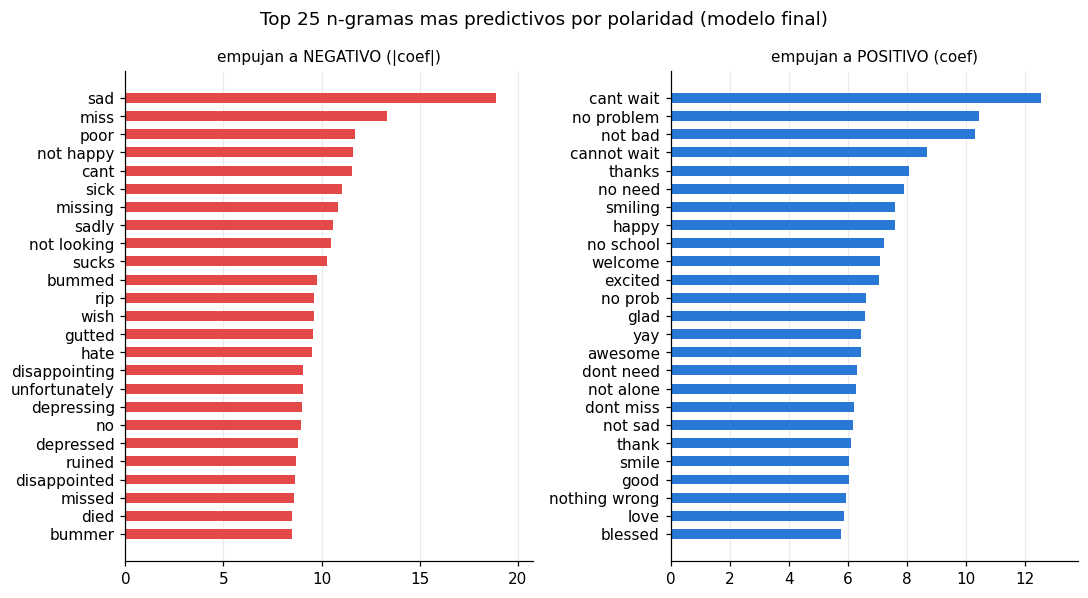

In [2]:
coefs = lr.coef_.ravel()
orden = np.argsort(coefs)
top_neg = pd.Series(coefs[orden[:25]], index=vocab[orden[:25]])
top_pos = pd.Series(coefs[orden[-25:]], index=vocab[orden[-25:]])

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
barras = axes[0].barh(top_neg.index[::-1], -top_neg.values[::-1], height=0.55, color=COLOR_NEG)
axes[0].set_title("empujan a NEGATIVO (|coef|)", fontsize=10)
barras = axes[1].barh(top_pos.index, top_pos.values, height=0.55, color=COLOR_POS)
axes[1].set_title("empujan a POSITIVO (coef)", fontsize=10)
for ax in axes:
    ax.grid(axis="y", alpha=0)
    ax.margins(x=0.1)
fig.suptitle("Top 25 n-gramas mas predictivos por polaridad (modelo final)")
fig.tight_layout()
guardar_fig(fig, "06_coeficientes.png")
plt.show()

Notese la diferencia con el EDA (notebook 02): palabras **frecuentes** como `work` o
`today` no estan entre las mas **predictivas**; en cambio aparecen terminos menos
frecuentes pero inequivocos (`sad`, `poor`, `hurts` vs `thanks`, `welcome`, `smile`)
y bigramas con negacion (`not happy`, `no fun`, `dont feel`), lo que valida haber
conservado las negaciones y usado `ngram_range=(1,2)`.

## 2. Similitud coseno (metrica vista en clase)

**Que se interpreta con esta metrica:** el coseno del angulo entre dos vectores
TF-IDF mide cuanto comparten dos tweets su vocabulario ponderado, ignorando la
longitud de cada texto. Vale 1 si usan exactamente los mismos terminos con las
mismas proporciones, 0 si no comparten ningun termino. Como los vectores de
`TfidfVectorizer` ya estan normalizados en L2, el coseno se reduce al producto punto.

Se usa para tres analisis:

1. **Vecinos mas cercanos** de un tweet: recupera tweets que hablan de lo mismo.
2. **Coherencia de etiquetas**: si tweets casi identicos tienen etiquetas opuestas,
   hay ruido de etiquetado (techo de performance).
3. **Centroides de clase**: cuanto se parecen, en promedio, el vocabulario positivo
   y el negativo.

In [3]:
# Matriz TF-IDF del corpus completo (los vectores salen normalizados en L2).
X = vec.transform(train["text_clean"])
print(f"Matriz TF-IDF: {X.shape[0]:,} x {X.shape[1]:,}")

Matriz TF-IDF: 1,600,000 x 379,089


In [4]:
def vecinos(idx_consulta, k=5):
    sims = (X @ X[idx_consulta].T).toarray().ravel()
    sims[idx_consulta] = -1  # excluye el propio tweet
    top = np.argsort(sims)[::-1][:k]
    print(f"CONSULTA [{ 'pos' if train.loc[idx_consulta, TARGET] == 4 else 'neg' }]: {train.loc[idx_consulta, 'text']}")
    for i in top:
        et = "pos" if train.loc[i, TARGET] == 4 else "neg"
        print(f"  cos={sims[i]:.3f} [{et}] {train.loc[i, 'text']}")
    print()

# Un tweet negativo y uno positivo cualesquiera como consultas.
vecinos(train.index[(train[TARGET] == 0)][7])
vecinos(train.index[(train[TARGET] == 4)][123])

CONSULTA [neg]: @LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?
  cos=0.536 [pos] @ladyblue3 HEY! long time no see! 
  cos=0.517 [neg] hey! long time no see 
  cos=0.459 [pos] @erinekath hey chennnn  long time no see
  cos=0.408 [pos] @YaBoyLyricz hey u! Long time 
  cos=0.397 [pos] @4300VIP hey! Long time no talk 

CONSULTA [pos]: @suitelifeofkell that's freakin' cooool   i love twitter .haha
  cos=0.537 [pos] @rickseibold that's freakin awesome!!! 
  cos=0.458 [pos] @GiulianaRancic that's freakin hilarous how funny 
  cos=0.453 [pos] i love twitter 
  cos=0.453 [pos] I LOVE TWITTER 
  cos=0.453 [pos] i love twitter 



In [5]:
# Coherencia de etiquetas: pares de tweets muy similares con etiquetas opuestas.
# Se buscan los vecinos mas cercanos de una muestra de consultas negativas y se
# reportan los casos con similitud alta y etiqueta contraria.
rng = np.random.default_rng(SEED)
consultas = rng.choice(train.index[train[TARGET] == 0], size=300, replace=False)
sims_bloque = (X[consultas] @ X.T).toarray()
sims_bloque[np.arange(len(consultas)), consultas] = -1

pares = []
for fila, iq in enumerate(consultas):
    j = sims_bloque[fila].argmax()
    if sims_bloque[fila, j] > 0.8 and train.loc[j, TARGET] != train.loc[iq, TARGET]:
        pares.append((sims_bloque[fila, j], train.loc[iq, "text"], train.loc[j, "text"]))

print(f"Pares (cos > 0.8) con etiquetas OPUESTAS encontrados: {len(pares)} de 300 consultas\n")
for s, a, b in sorted(pares, reverse=True)[:5]:
    print(f"cos={s:.3f}")
    print(f"  [neg] {a}")
    print(f"  [pos] {b}")
    print()

Pares (cos > 0.8) con etiquetas OPUESTAS encontrados: 1 de 300 consultas

cos=1.000
  [neg] two exams down  8 more to go though  !
  [pos] two exams down  8 more to go though  !



In [6]:
# Centroides de clase: vector TF-IDF promedio de cada polaridad.
def centroide(mask):
    c = np.asarray(X[mask.to_numpy()].mean(axis=0)).ravel()
    return c / np.linalg.norm(c)

c_neg = centroide(train[TARGET] == 0)
c_pos = centroide(train[TARGET] == 4)
print(f"Similitud coseno entre el centroide negativo y el positivo: {c_neg @ c_pos:.3f}")

Similitud coseno entre el centroide negativo y el positivo: 0.894


Los centroides son **muy parecidos** (coseno alto): ambas clases comparten la enorme
mayoria del vocabulario cotidiano (pronombres, verbos comunes, temas diarios) y solo
una fraccion chica de terminos carga el sentimiento. Por eso un modelo lineal
funciona: no necesita separar el tema, solo pesar esa fraccion discriminante.

## 3. Topicos por polaridad (NMF)

Para responder "de que hablan los tweets negativos y positivos" se factoriza la
matriz TF-IDF de cada clase con **NMF** (mini-batch, por el volumen). Se usa un
vocabulario reducido a unigramas informativos para que los topicos sean legibles.
Todas las filas de cada clase participan (800.000 por polaridad).

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_topicos = list(ENGLISH_STOP_WORDS | {"xxuser", "xxurl", "im", "amp", "quot", "dont", "just", "like", "got", "know", "really"})


def topicos_clase(textos, n_topicos=8, top_palabras=8):
    vec_t = TfidfVectorizer(stop_words=stop_topicos, max_features=20_000, min_df=20)
    Xt = vec_t.fit_transform(textos)
    nmf = MiniBatchNMF(n_components=n_topicos, batch_size=4096, random_state=SEED)
    nmf.fit(Xt)
    palabras = vec_t.get_feature_names_out()
    filas = []
    for k, comp in enumerate(nmf.components_):
        top = palabras[np.argsort(comp)[::-1][:top_palabras]]
        filas.append({"topico": k + 1, "palabras": ", ".join(top)})
    return pd.DataFrame(filas)


print("Topicos en tweets NEGATIVOS (800.000 tweets):")
topicos_clase(train.loc[train[TARGET] == 0, "text_clean"])

Topicos en tweets NEGATIVOS (800.000 tweets):


,topico,palabras
0,1,"today, work, good, tomorrow, feel, bad, time, sick"
1,2,"miss, gonna, love, going, ill, friends, good, home"
2,3,"work, miss, link, ready, boyfriend, youu, youuu, dearly"
3,4,"want, home, doesnt, sleep, leave, come, bed, new"
4,5,"sad, makes, thats, face, love, leaving, movie, make"
5,6,"sorry, hear, oh, feel, hope, sucks, didnt, better"
6,7,"wish, sleep, going, home, bed, tired, need, night"
7,8,"day, wish, long, fathers, having, sorry, rainy, happy"


In [8]:
print("Topicos en tweets POSITIVOS (800.000 tweets):")
topicos_clase(train.loc[train[TARGET] == 4, "text_clean"])

Topicos en tweets POSITIVOS (800.000 tweets):


,topico,palabras
0,1,"good, morning, night, luck, hope, thanks, day, today"
1,2,"thanks, follow, followfriday, following, ff, hey, guys, ill"
2,3,"love, song, new, great, guys, haha, today, amazing"
3,4,"day, great, mothers, today, happy, hope, nice, work"
4,5,"thank, followfriday, god, follow, following, ff, good, appreciate"
5,6,"time, haha, going, night, thats, fun, lol, twitter"
6,7,"lol, happy, day, mothers, birthday, morning, ur, followers"
7,8,"happy, morning, birthday, twitter, going, welcome, mothers, new"


Los topicos negativos giran alrededor de **trabajo/estudio, salud/dolor, extraniar
a alguien y fallas** (telefono, internet); los positivos alrededor de **saludos y
agradecimientos, humor, musica/eventos y planes**. El "tema" y la "polaridad" estan
entrelazados: algunos temas concentran una polaridad casi por definicion.

## 4. Errores del modelo: sarcasmo y ambiguedad

Se retoman los errores mas confiados de la notebook 05 buscando el patron tipico
del sarcasmo: **vocabulario literalmente positivo en tweets etiquetados negativos**.

In [9]:
val = pd.read_parquet(DATA_PROCESSED / "val_predicciones.parquet")
val_txt = val.join(train.loc[val["idx"], ["text", "text_clean"]].reset_index(drop=True))

palabras_pos = {"great", "amazing", "awesome", "love", "nice", "fun", "yay", "wonderful", "perfect", "brilliant"}
mask_sarcasmo = (
    (val_txt["y_true"] == 0)
    & (val_txt["proba_pos"] >= 0.7)
    & val_txt["text_clean"].str.split().apply(lambda t: bool(palabras_pos & set(t)))
)
candidatos = val_txt[mask_sarcasmo].nlargest(8, "proba_pos")
print(f"Tweets NEGATIVOS con vocabulario positivo que confundieron al modelo: {mask_sarcasmo.sum():,}\n")
for _, r in candidatos.iterrows():
    print(f"  p(pos)={r['proba_pos']:.3f} | {r['text']}")

Tweets NEGATIVOS con vocabulario positivo que confundieron al modelo: 1,077

  p(pos)=0.996 | Great. History. Yay... 
  p(pos)=0.995 | @JonasAustralia That quote is amazing. I almost have up on love  Thank you.
  p(pos)=0.993 | @thisisjulze goood luccck love *L( 
  p(pos)=0.992 | http://bit.ly/Ai4a1  wow!  love it!
  p(pos)=0.991 | @mcraddictal I love Drew from Mytoecold. I find a sense of really good sarcastic humor very sexy....haha 
  p(pos)=0.991 | @Ms_Balla32 sorry  it was a great meet! Thanks for following...
  p(pos)=0.987 | Shower time is fun. Yay. Drivers training today 
  p(pos)=0.986 | Off to do 1,000 chores.  Yay. Have a great day, everyone. ? http://blip.fm/~4j6he


Varios de estos errores son **ironicos o sarcasticos**: palabras positivas usadas en
contexto negativo. Un modelo de bolsa de palabras no tiene forma de detectar esa
inversion de sentido: es una limitacion estructural del enfoque, no un bug. Tambien
aparecen tweets genuinamente **ambiguos** o con la parte negativa implicita, donde
la etiqueta automatica original (por emoticones) es discutible.

## 5. Extension: tendencia de polaridad por usuario

Se agrega el corpus por usuario y se calcula la proporcion observada de tweets
negativos (`pesimismo_observado`). Solo usuarios con **20 o mas tweets** para evitar
rankings inestables. Es una **tendencia observada en este corpus**, no un diagnostico
sobre personas.

Usuarios totales: 659,775 | con >= 20 tweets: 6,245


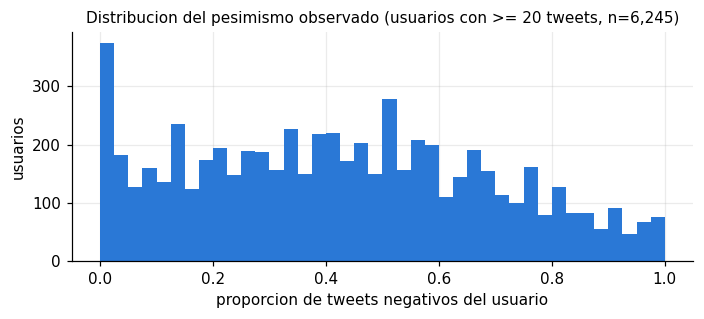

In [10]:
por_usuario = (
    train.assign(es_neg=(train[TARGET] == 0))
    .groupby("user")
    .agg(n_tweets=("es_neg", "size"), pesimismo_observado=("es_neg", "mean"))
)
activos = por_usuario[por_usuario["n_tweets"] >= 20].sort_values("pesimismo_observado")
print(f"Usuarios totales: {len(por_usuario):,} | con >= 20 tweets: {len(activos):,}")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(activos["pesimismo_observado"], bins=40, color="#2a78d6")
ax.set_xlabel("proporcion de tweets negativos del usuario")
ax.set_ylabel("usuarios")
ax.set_title(f"Distribucion del pesimismo observado (usuarios con >= 20 tweets, n={len(activos):,})", fontsize=10)
fig.tight_layout()
guardar_fig(fig, "06_pesimismo_usuarios.png")
plt.show()

In [11]:
print("Usuarios con mayor proporcion NEGATIVA:")
print(activos.tail(5).iloc[::-1].round(3))
print()
print("Usuarios con mayor proporcion POSITIVA:")
print(activos.head(5).round(3))
print()
usuario_extremo = activos.index[-1]
print(f"Ejemplos de @{usuario_extremo}:")
for t in train.loc[train['user'] == usuario_extremo, 'text'].head(4):
    print("  -", t)

Usuarios con mayor proporcion NEGATIVA:
               n_tweets  pesimismo_observado
user                                        
delphilicious        25                  1.0
Elaine_W_84          37                  1.0
ShinesFresh          21                  1.0
sln25373             20                  1.0
sky14kemea           38                  1.0

Usuarios con mayor proporcion POSITIVA:
                 n_tweets  pesimismo_observado
user                                          
Recamel                71                  0.0
StarrahPenzHitz        24                  0.0
rotkapchen             20                  0.0
ruhanirabin            66                  0.0
BlokesLib             109                  0.0

Ejemplos de @delphilicious:
  - @ElleCMcG OMG recap  Sorry you had a crazy day, Laura!
  - I just got a lot of free shot up my nose. Gross. Anyone find my keys? 
  - Still no keys. Sigh. This is going to cost a lot to replace 
  - We just finished 10 seasons of Friends in t

La distribucion es amplia, con un **pico marcado en 0** (usuarios que solo aparecen
con tweets positivos) y una cola no menor de usuarios siempre negativos: una parte de
los usuarios activos aparece en el corpus con una sola polaridad. Esto es en parte un artefacto del muestreo del
dataset (se recolectaron tweets por emoticon, no lineas de tiempo completas), otra
razon para leer el score como tendencia del corpus y no como rasgo de la persona.

## Conclusiones del TP

1. **El modelo funciona:** TF-IDF (1-2 gramas) + Logistic Regression, entrenado con
   los 1.600.000 tweets, clasifica polaridad con metricas solidas tanto en
   validacion como en el test manual de dominio distinto.
2. **La senial es lexica y las negaciones importan:** los n-gramas mas predictivos
   son emocionales e inequivocos; los bigramas con negacion aportan.
3. **La similitud coseno** mostro que ambas polaridades comparten casi todo el
   vocabulario (centroides muy similares) y sirvio para detectar tweets casi
   identicos con etiquetas opuestas: hay ruido de etiquetado que pone un techo.
4. **Limitaciones:** sarcasmo/ironia (estructuralmente invisible para bolsa de
   palabras), clase neutral ausente en training (la extension por umbral tiene techo
   bajo) y etiquetas automaticas ruidosas.
5. **Mejora futura:** un modelo preentrenado de lenguaje (embeddings contextuales)
   para capturar ironia y contexto, y datos neutrales reales para el problema de
   3 clases.